# Model Training and Testing
This notebook train the model based on the features of the datset and test the model how it is performing.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

In [4]:
df = pd.read_csv("../data/stud.csv")

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
target = "math_score"
X = df.drop(columns = [target])
y = df[target]

In [41]:
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [42]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [8]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

C:\Users\USER PC\AppData\Local\Temp\ipykernel_12744\411296460.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numerical",
        StandardScaler(),
        numerical_features
    )
    ]

)

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

In [44]:
results = []
for model_name, model in models.items():
    pipeline = Pipeline(
        steps = [
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results.append({
        "Model": model_name,
        "MSE": mean_squared_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "MAE": mean_absolute_error(y_test, predictions),
        "R2": r2_score(y_test, predictions),
        "predictions" : predictions

    })

results_df  = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df)   

               Model        MSE      RMSE       MAE        R2  \
2   Lasso Regression  28.984471  5.383723  4.204587  0.880888   
1   Ridge Regression  29.056602  5.390418  4.211113  0.880592   
0  Linear Regression  29.095170  5.393994  4.214763  0.880433   
5  Gradient Boosting  31.518192  5.614106  4.315213  0.870476   
4      Random Forest  35.792494  5.982683  4.620434  0.852911   
3      Decision Tree  60.520000  7.779460  6.240000  0.751293   

                                         predictions  
2  [76.4277797385801, 58.810358581091066, 77.0726...  
1  [76.39874628164999, 58.84316508851742, 76.9920...  
0  [76.38796970470777, 58.88597003651174, 76.9902...  
5  [74.1361327387949, 55.25738897362971, 78.03516...  
4  [77.395, 54.645, 77.095, 77.205, 80.385, 85.35...  
3  [85.0, 60.0, 74.0, 69.0, 76.0, 88.0, 61.0, 52....  


In [45]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

best_pipeline.fit(X_train, y_train)
best_predictions =best_pipeline.predict(X_test)

In [46]:
print("Best Model:", best_model_name)
print("MAE:", mean_absolute_error(y_test, best_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test,best_predictions)))
print("R2 Score:", r2_score(y_test, best_predictions))

Best Model: Lasso Regression
MAE: 4.204586505968743
RMSE: 5.383722811732324
R2 Score: 0.8808882144636153


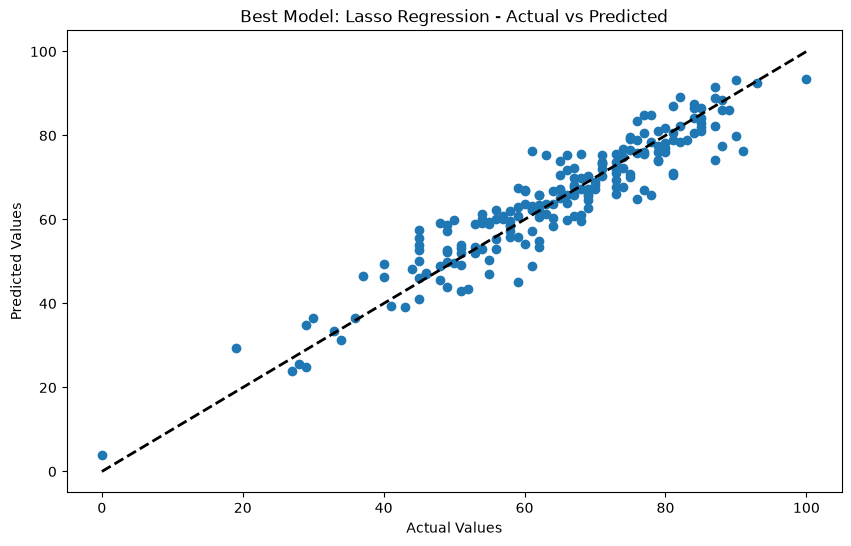

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f"Best Model: {best_model_name} - Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()  

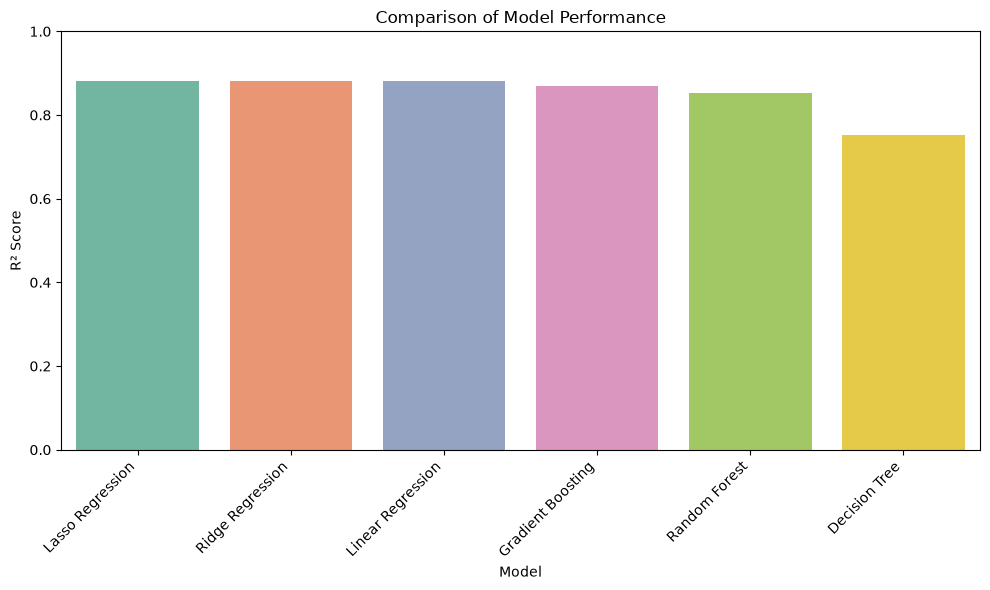

In [48]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Comparison of Model Performance")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

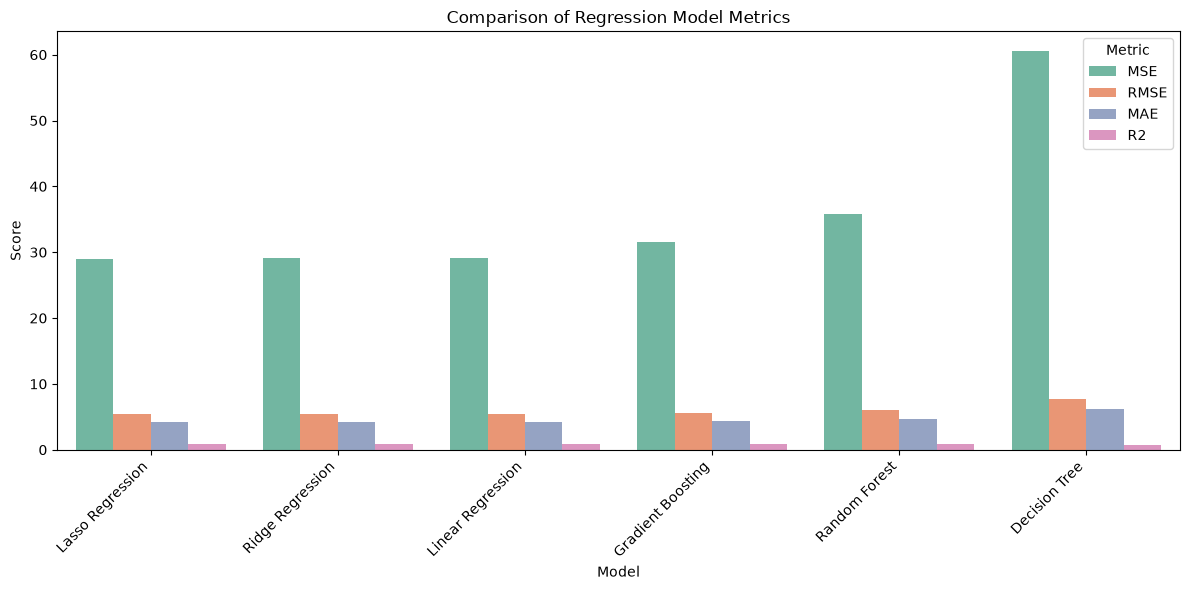

In [54]:
metrics = ["MSE", "RMSE", "MAE","R2"]

results_long = results_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title("Comparison of Regression Model Metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

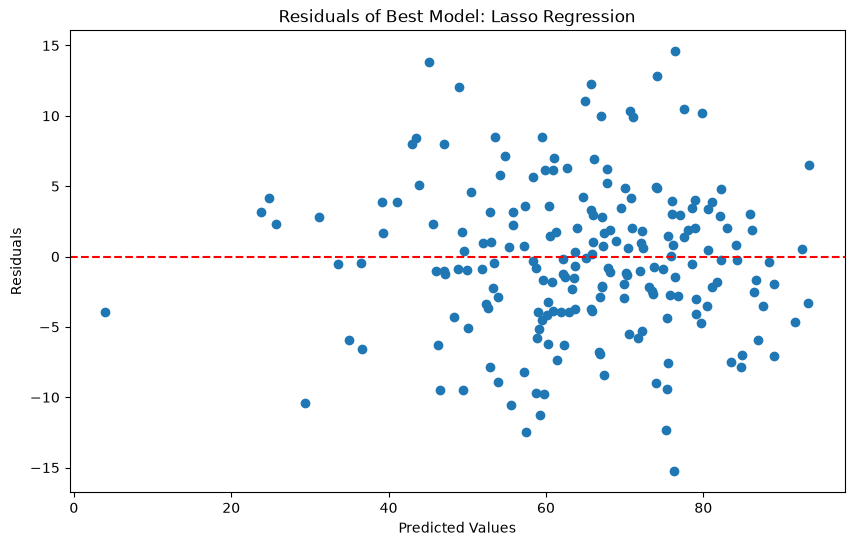

In [50]:
residuals = y_test - best_predictions

plt.figure(figsize=(10,6))
plt.scatter(x=best_predictions, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f"Residuals of Best Model: {best_model_name}")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [52]:


data = pd.DataFrame({
    "Actual": y_test,
    "Predicted Value": best_predictions,
    "residuals": residuals
})

In [53]:
data

,Actual,Predicted Value,residuals
521,91,76.427780,14.572220
737,53,58.810359,-5.810359
740,80,77.072604,2.927396
660,74,76.771204,-2.771204
411,84,87.525560,-3.525560
...,...,...,...
408,52,43.540669,8.459331
332,62,62.203067,-0.203067
208,74,67.804718,6.195282
613,65,67.099710,-2.099710


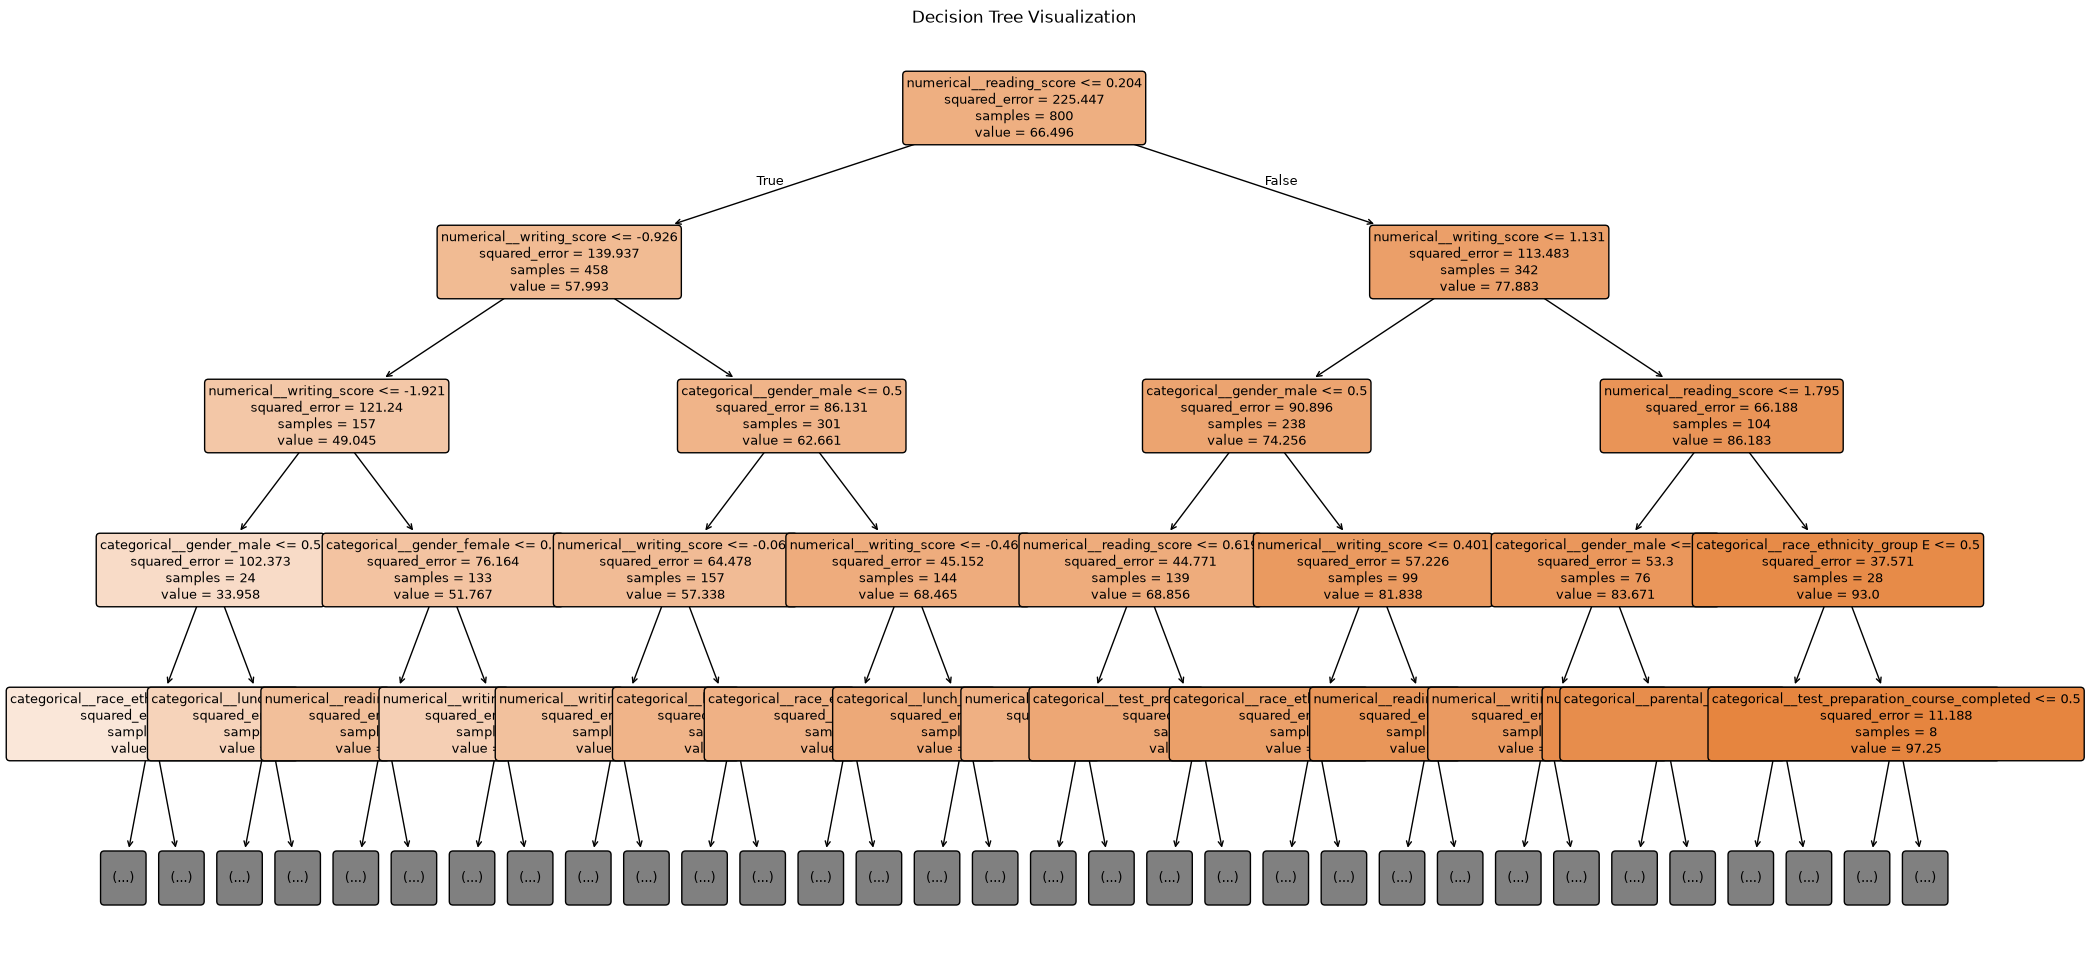

In [59]:
from sklearn.tree import plot_tree
X_train_transformed = preprocessor.fit_transform(X_train)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_transformed, y_train)


feature_names = preprocessor.get_feature_names_out()

# Visualize the tree
plt.figure(figsize=(24, 12))

plot_tree(
    dt,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth = 4
)

plt.title("Decision Tree Visualization")
plt.show()

In [61]:
import joblib

joblib.dump(best_pipeline, "../artifacts/best_model.pkl")
print("Best model saved successfully.")

Best model saved successfully.


In [63]:
print(results_df[["Model", "MAE", "RMSE", "R2"]])

best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

               Model       MAE      RMSE        R2
2   Lasso Regression  4.204587  5.383723  0.880888
1   Ridge Regression  4.211113  5.390418  0.880592
0  Linear Regression  4.214763  5.393994  0.880433
5  Gradient Boosting  4.315213  5.614106  0.870476
4      Random Forest  4.620434  5.982683  0.852911
3      Decision Tree  6.240000  7.779460  0.751293
Best Model: Lasso Regression
